## 1. Setup & Imports

In [1]:
# On Kaggle these are almost all pre-installed. Uncomment installs if a package is missing.
# !pip install -q transformers datasets evaluate seqeval gradio nltk scikit-learn

import os, re, json, random, string, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


## 2. Load Data

The CFPB-style dataset has (at minimum) two columns:
- `product` — the complaint category label (e.g. `credit_card`, `credit_reporting`,
  `retail_banking`, `mortgages_and_loans`, `debt_collection`).
- `narrative` — the free-text customer complaint.

Update `DATA_PATH` for wherever your file lives (Kaggle input dataset, or
`/kaggle/working/your_file.csv` if you uploaded it directly).

In [3]:
DATA_PATH = "/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv"  # <-- EDIT ME

if not os.path.exists(DATA_PATH):
    # fallback for local/py310 runs outside Kaggle
    DATA_PATH = "complaints_processed.csv"

df = pd.read_csv(DATA_PATH)
# keep only the columns we need, drop an unnamed index column if present
df = df[[c for c in df.columns if c.lower() in ("product", "narrative")]]
df.columns = [c.lower() for c in df.columns]
df = df.dropna(subset=["product", "narrative"]).reset_index(drop=True)
print(df.shape)
df.head()


(162411, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


## 3. Exploratory Data Analysis — Class Distribution

product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


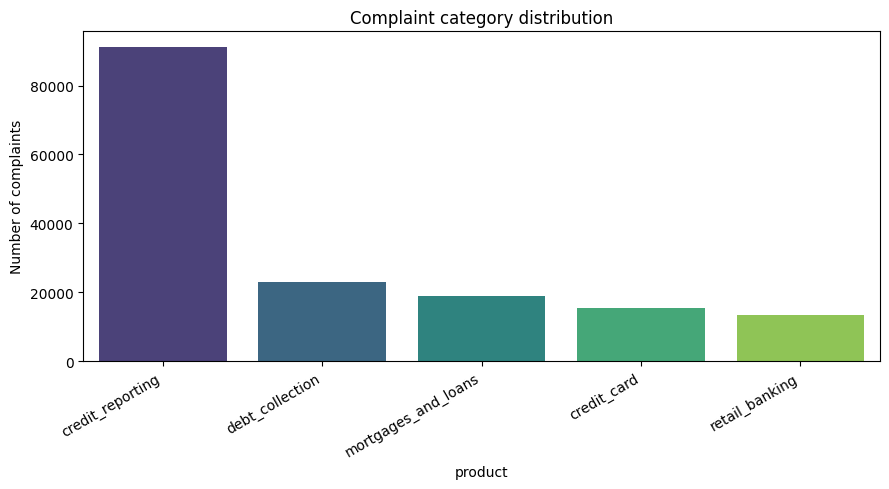


Class imbalance ratio (max/min): 6.74


In [4]:
class_counts = df["product"].value_counts()
print(class_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Complaint category distribution")
plt.ylabel("Number of complaints")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nClass imbalance ratio (max/min):",
      round(class_counts.max() / class_counts.min(), 2))


## 4. Text Preprocessing

- Lowercasing
- Removing punctuation, numbers, and special characters
- Removing stop words
- Lemmatization

(Some CFPB narrative exports arrive already lowercased/stopword-stripped — this
pipeline is idempotent, so it's safe either way.)

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # remove numbers/punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df["clean_narrative"] = df["narrative"].apply(clean_text)
df = df[df["clean_narrative"].str.len() > 0].reset_index(drop=True)
df[["narrative", "clean_narrative"]].head()


,narrative,clean_narrative
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


## 5. Label Encoding & Train/Test Split

In [6]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["product"])
num_classes = df["label"].nunique()
class_names = list(le.classes_)
print("Classes:", class_names)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_narrative"].values, df["label"].values,
    test_size=0.2, random_state=SEED, stratify=df["label"].values
)
print("Train:", len(X_train_text), " Test:", len(X_test_text))


Classes: ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']
Train: 129928  Test: 32483


### Handling class imbalance
We compute per-class weights so the loss function penalizes mistakes on minority
classes more heavily — cheaper and safer than duplicating/dropping rows.

In [7]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print(class_weight_dict)


{0: np.float64(2.086693969324661), 1: np.float64(0.3562745931420267), 2: np.float64(1.4032616913273572), 3: np.float64(1.7104791995787256), 4: np.float64(2.3998522349464353)}


## 6. Tokenization & Padding (for the RNN-family models)

In [8]:
VOCAB_SIZE = 20000
MAX_LEN = 150          # tune based on df["clean_narrative"].str.split().str.len().describe()
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(X_train_pad.shape, X_test_pad.shape)


(129928, 150) (32483, 150)


## 7. Build & Train SimpleRNN / LSTM / GRU

Each model shares the same embedding size, sequence length, and training setup so the
comparison in Section 9 is apples-to-apples.

In [9]:
def build_model(rnn_type="lstm", bidirectional=False):
    model = Sequential(name=f"{rnn_type}_model")
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))

    if rnn_type == "simplernn":
        layer = SimpleRNN(64, dropout=0.3, recurrent_dropout=0.2)
    elif rnn_type == "lstm":
        layer = LSTM(64, dropout=0.3, recurrent_dropout=0.2)
    elif rnn_type == "gru":
        layer = GRU(64, dropout=0.3, recurrent_dropout=0.2)
    else:
        raise ValueError(rnn_type)

    model.add(Bidirectional(layer) if bidirectional else layer)
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

EPOCHS = 10
BATCH_SIZE = 64

histories = {}
keras_models = {}

for rnn_type in ["simplernn", "lstm", "gru"]:
    print(f"\n===== Training {rnn_type.upper()} =====")
    model = build_model(rnn_type)
    es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    history = model.fit(
        X_train_pad, y_train_cat,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=[es],
        verbose=1
    )
    histories[rnn_type] = history.history
    keras_models[rnn_type] = model



===== Training SIMPLERNN =====


I0000 00:00:1784738072.912399      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784738072.915884      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10
   6/1828 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.2023 - loss: 2.0462

I0000 00:00:1784738080.026480      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1828/1828 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.2757 - loss: 1.6157 - val_accuracy: 0.5416 - val_loss: 1.5758
Epoch 2/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.4452 - loss: 1.6023 - val_accuracy: 0.5402 - val_loss: 1.5810
Epoch 3/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.5345 - loss: 1.5934 - val_accuracy: 0.5473 - val_loss: 1.5741
Epoch 4/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.5143 - loss: 1.5884 - val_accuracy: 0.5644 - val_loss: 1.5422
Epoch 5/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.5246 - loss: 1.5811 - val_accuracy: 0.5484 - val_loss: 1.5620
Epoch 6/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.5155 - loss: 1.5780 - val_accuracy: 0.5470 - val_loss: 1.5542

===== Training LSTM =====
Epoch 1/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 974s 528ms/step - accuracy: 0.4485 - loss: 1.3182 - val_accuracy: 0.5962 - val_loss: 1.1156
Epoch 2/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 997s 546ms/step 

## 8. Fine-tune a Transformer 

In [10]:
import transformers
import datasets
import torch

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PyTorch:", torch.__version__)

Transformers: 5.0.0
Datasets: 5.0.0
PyTorch: 2.10.0+cu128


In [11]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

MODEL_CHECKPOINT = "distilbert-base-uncased"

# Tokenizer
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# Datasets
train_ds = Dataset.from_dict({
    "text": list(X_train_text),
    "label": list(y_train),
})

test_ds = Dataset.from_dict({
    "text": list(X_test_text),
    "label": list(y_test),
})

# Tokenization
def hf_tokenize(batch):
    return hf_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(hf_tokenize, batched=True)
test_ds = test_ds.map(hf_tokenize, batched=True)

# Dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)

# Model
hf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=num_classes,
)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }

# Training arguments
training_args = TrainingArguments(
    output_dir="/kaggle/working/hf_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

# Trainer (Transformers 5.0.0)
trainer = Trainer(
    model=hf_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=hf_tokenizer,   # <-- New in v5
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/129928 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=12183, training_loss=0.6261635315904552, metrics={'train_runtime': 3726.4762, 'train_samples_per_second': 104.599, 'train_steps_per_second': 3.269, 'total_flos': 1.512006029868504e+16, 'train_loss': 0.6261635315904552, 'epoch': 3.0})

## 9. Evaluate & Compare All Four Models

Metrics: Accuracy, Precision, Recall, F1-score (macro-averaged, since classes are
imbalanced) and confusion matrices.


=== SIMPLERNN ===
                     precision    recall  f1-score   support

        credit_card       0.14      0.02      0.03      3113
   credit_reporting       0.59      0.95      0.73     18235
    debt_collection       0.54      0.02      0.03      4630
mortgages_and_loans       0.50      0.17      0.25      3798
     retail_banking       0.16      0.08      0.11      2707

           accuracy                           0.57     32483
          macro avg       0.39      0.25      0.23     32483
       weighted avg       0.50      0.57      0.46     32483



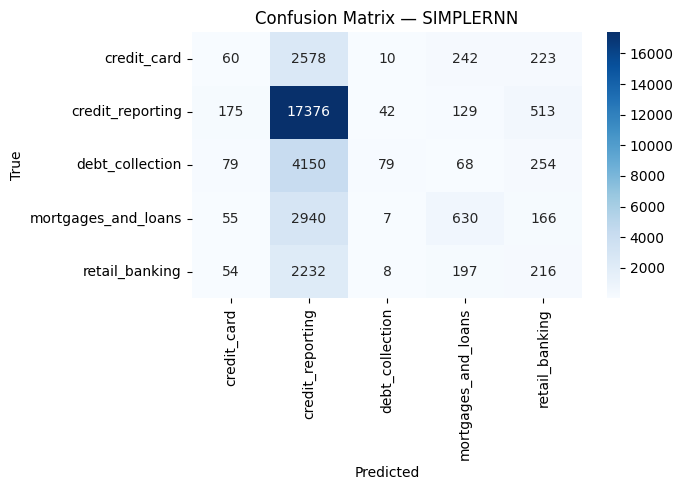


=== LSTM ===
                     precision    recall  f1-score   support

        credit_card       0.68      0.85      0.75      3113
   credit_reporting       0.96      0.85      0.90     18235
    debt_collection       0.71      0.83      0.77      4630
mortgages_and_loans       0.79      0.85      0.82      3798
     retail_banking       0.84      0.88      0.86      2707

           accuracy                           0.85     32483
          macro avg       0.80      0.85      0.82     32483
       weighted avg       0.87      0.85      0.86     32483



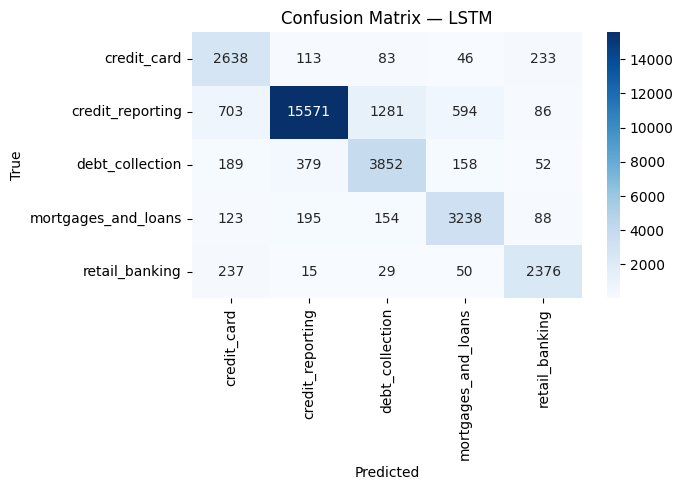


=== GRU ===
                     precision    recall  f1-score   support

        credit_card       0.69      0.84      0.76      3113
   credit_reporting       0.96      0.85      0.90     18235
    debt_collection       0.72      0.83      0.77      4630
mortgages_and_loans       0.78      0.88      0.83      3798
     retail_banking       0.84      0.90      0.87      2707

           accuracy                           0.85     32483
          macro avg       0.80      0.86      0.83     32483
       weighted avg       0.87      0.85      0.86     32483



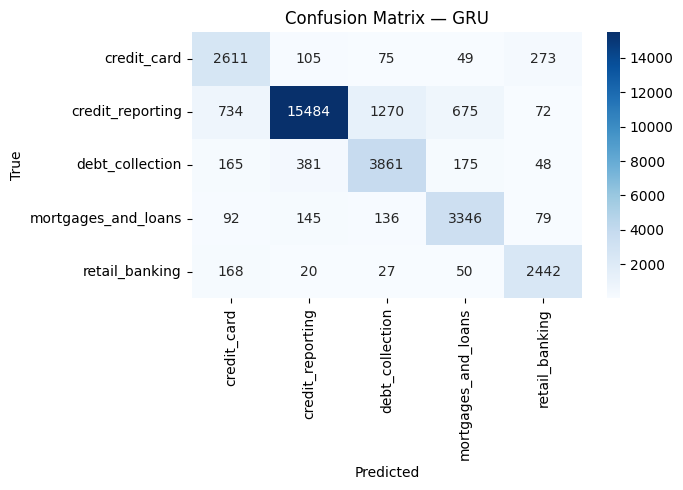

In [12]:
results = {}

def evaluate_keras(model, name):
    probs = model.predict(X_test_pad, verbose=0)
    preds = np.argmax(probs, axis=1)
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average="macro", zero_division=0),
        "recall": recall_score(y_test, preds, average="macro", zero_division=0),
        "f1": f1_score(y_test, preds, average="macro", zero_division=0),
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return preds

for rnn_type, model in keras_models.items():
    evaluate_keras(model, rnn_type.upper())


                     precision    recall  f1-score   support

        credit_card       0.83      0.81      0.82      3113
   credit_reporting       0.93      0.95      0.94     18235
    debt_collection       0.84      0.80      0.82      4630
mortgages_and_loans       0.88      0.83      0.86      3798
     retail_banking       0.88      0.90      0.89      2707

           accuracy                           0.90     32483
          macro avg       0.87      0.86      0.87     32483
       weighted avg       0.90      0.90      0.90     32483



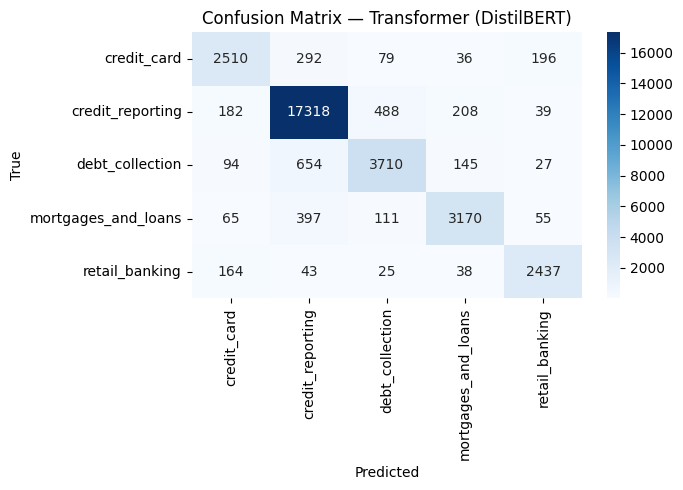

In [13]:
# Transformer evaluation
hf_preds_output = trainer.predict(test_ds)
hf_preds = np.argmax(hf_preds_output.predictions, axis=1)

results["Transformer (DistilBERT)"] = {
    "accuracy": accuracy_score(y_test, hf_preds),
    "precision": precision_score(y_test, hf_preds, average="macro", zero_division=0),
    "recall": recall_score(y_test, hf_preds, average="macro", zero_division=0),
    "f1": f1_score(y_test, hf_preds, average="macro", zero_division=0),
}
print(classification_report(y_test, hf_preds, target_names=class_names, zero_division=0))
cm = confusion_matrix(y_test, hf_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Transformer (DistilBERT)")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()


                          accuracy  precision    recall        f1
Transformer (DistilBERT)  0.897239   0.873057  0.858443  0.865443
GRU                       0.854108   0.797685  0.860976  0.825550
LSTM                      0.851984   0.795807  0.852713  0.820577
SIMPLERNN                 0.565250   0.386306  0.246980  0.230639


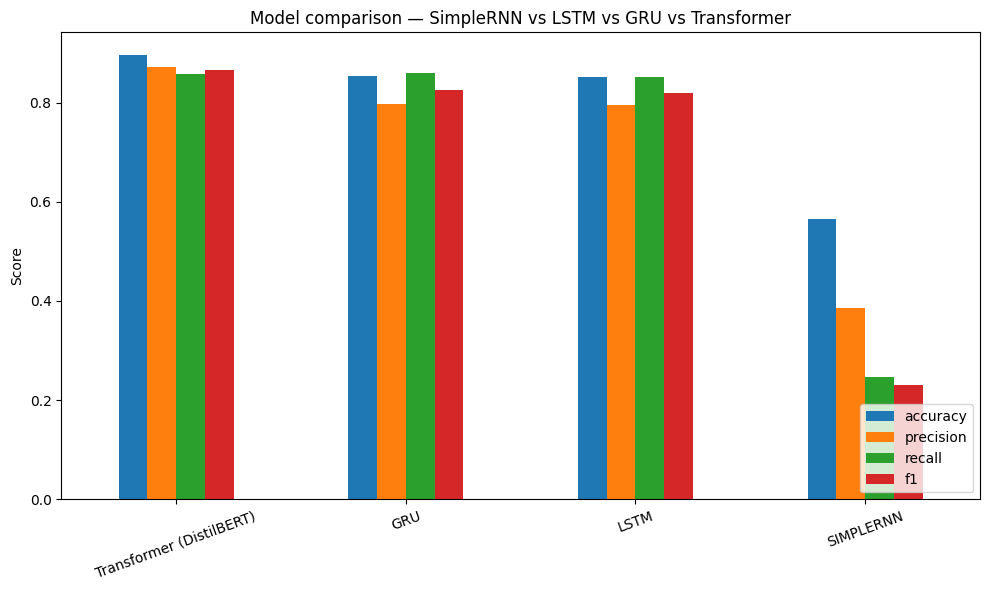


Best model: Transformer (DistilBERT)


In [14]:
results_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
print(results_df)

results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model comparison — SimpleRNN vs LSTM vs GRU vs Transformer")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

BEST_MODEL_NAME = results_df.index[0]
print(f"\nBest model: {BEST_MODEL_NAME}")


## 10. Save Everything Needed for Deployment

In [15]:
os.makedirs("/kaggle/working/saved_models", exist_ok=True)
os.makedirs("/kaggle/working/artifacts", exist_ok=True)

# Save all Keras models (small, cheap to keep all three for the report)
for rnn_type, model in keras_models.items():
    model.save(f"/kaggle/working/saved_models/{rnn_type}.keras")

# Save the Transformer (only if it's the winner, or always — it's useful either way)
trainer.save_model("/kaggle/working/saved_models/transformer_best")
hf_tokenizer.save_pretrained("/kaggle/working/saved_models/transformer_best")

# Save tokenizer, label encoder and config needed to reproduce preprocessing at inference time
with open("/kaggle/working/artifacts/keras_tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())

import pickle
with open("/kaggle/working/artifacts/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

config = {
    "best_model": BEST_MODEL_NAME,
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "class_names": class_names,
}
with open("/kaggle/working/artifacts/config.json", "w") as f:
    json.dump(config, f, indent=2)

results_df.to_csv("/kaggle/working/artifacts/model_comparison.csv")

print("Saved. Download the /kaggle/working/saved_models and /kaggle/working/artifacts")
print("folders (Output tab) and place them next to app.py for local deployment.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved. Download the /kaggle/working/saved_models and /kaggle/working/artifacts
folders (Output tab) and place them next to app.py for local deployment.


## 11. Inference Helper (used by the deployment app)

This mirrors exactly what `app.py` (the separate deployment script) does, so you can
sanity-check predictions right here in the notebook before deploying.

In [16]:
def predict_complaint(text, model_choice=None):
    model_choice = model_choice or BEST_MODEL_NAME
    cleaned = clean_text(text)

    if model_choice == "Transformer (DistilBERT)":
        import torch
        inputs = hf_tokenizer(cleaned, return_tensors="pt", truncation=True, max_length=MAX_LEN)
        inputs = {k: v.to(hf_model.device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = hf_model(**inputs).logits
        probs = logits.softmax(dim=-1).cpu().numpy()[0]
    else:
        model = keras_models[model_choice.lower()]
        seq = tokenizer.texts_to_sequences([cleaned])
        pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
        probs = model.predict(pad, verbose=0)[0]

    idx = int(np.argmax(probs))
    return class_names[idx], float(probs[idx])

# quick sanity check
sample = "my credit card company charged me a late fee even though i paid on time"
label, conf = predict_complaint(sample)
print(f"Prediction: {label}  (confidence {conf:.2%})")

Prediction: credit_card  (confidence 94.38%)


## 12. Deploy (Gradio) — quick preview inside this notebook

This launches a temporary public Gradio link directly from Kaggle so you can demo the
model immediately. For a persistent local deployment, use the separate `app.py` +
`requirements.txt` (see the note in Section 0) in your local **py310** environment.

In [17]:
import gradio as gr

def gradio_predict(text):
    label, conf = predict_complaint(text)
    return f"{label}  (confidence: {conf:.1%})"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=5, label="Complaint narrative",
                       placeholder="Type or paste a customer complaint..."),
    outputs=gr.Textbox(label="Predicted category"),
    title="Consumer Complaint Classifier",
    description=f"Best model: {BEST_MODEL_NAME}. Enter a complaint narrative to classify it.",
)

demo.launch(share=True)  # share=True gives you a public link from Kaggle


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://484794aa3ff3ec1c48.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
